In [24]:
#.import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
#.load both datsets
df1=pd.read_csv("retail_sales_dataset.csv")
df2=pd.read_csv("menu.csv")
print(df1.head())
print(df2.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (1

In [26]:
#1.data cleaning
print(df1.isnull().sum())
print(df2.isnull().sum())

#fill missing values
df1.fillna(method='ffill',inplace=True)
df2.fillna(method='ffill',inplace=True)

#remove duplicates
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Category                         0
Item                             0
Serving Size                     0
Calories                         0
Calories from Fat                0
Total Fat                        0
Total Fat (% Daily Value)        0
Saturated Fat                    0
Saturated Fat (% Daily Value)    0
Trans Fat                        0
Cholesterol                      0
Cholesterol (% Daily Value)      0
Sodium                           0
Sodium (% Daily Value)           0
Carbohydrates                    0
Carbohydrates (% Daily Value)    0
Dietary Fiber                    0
Dietary Fiber (% Daily Value)    0
Sugars                           0
Protein                          0
Vitamin A (% Daily Value)        0
Vitamin C (% Daily Value)        0
Calcium (% Daily Va

C:\Users\vedashree k a\AppData\Local\Temp\ipykernel_4640\437392903.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1.fillna(method='ffill',inplace=True)
C:\Users\vedashree k a\AppData\Local\Temp\ipykernel_4640\437392903.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2.fillna(method='ffill',inplace=True)


In [27]:
#2.descriptive satistics
print(df1.describe())
print(df2.describe())



       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000
          Calories  Calories from Fat   Total Fat  Total Fat (% Daily Value)  \
count   260.000000         260.000000  260.000000                 260.000000   
mean    368.269231         127.096154   14.165385                  21.815385   
std     240.269886         127.875914   14.205998                  

In [28]:
print(df1.columns)

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [29]:
print(df1.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


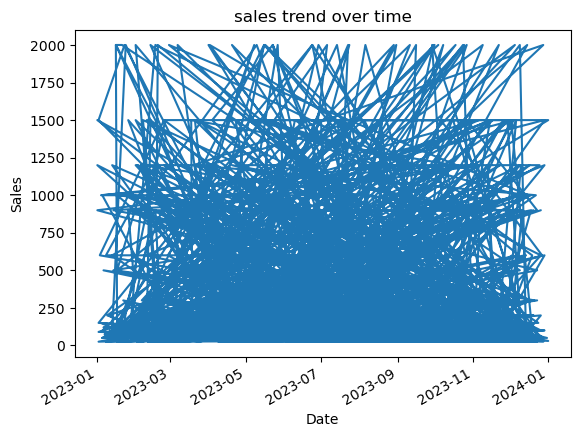

In [30]:
#3.time series analysis
df1['Date']=pd.to_datetime(df1['Date'])

#set index
df1.set_index('Date',inplace=True)

#ploi sales over time
plt.figure()
df1['Total Amount'].plot()
plt.title("sales trend over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [33]:
#4.customer & product analysis
top_products=df1.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
print(top_products.head())

#customer analysis
customer_sales=df1.groupby('Customer ID')['Total Amount'].sum()
print(customer_sales.head())

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64
Customer ID
CUST001     150
CUST002    1000
CUST003      30
CUST004     500
CUST005     100
Name: Total Amount, dtype: int64


In [ ]:
#